<a href="https://colab.research.google.com/github/24Sinchana/project/blob/main/ML%20PROJECTS/MNIST_Digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#image recognition problems
#import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2  #open Cv library
from google.colab.patches import cv2_imshow #used to dispaly image
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras #create NN
from keras.datasets import mnist #library
from tensorflow.math import confusion_matrix

In [2]:
#loading MNIST dataset from keras
#we have processed data here
(X_train ,Y_train),(X_test,Y_test)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
type(X_train)

numpy.ndarray

In [4]:
#shape of numpy array
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)



(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [5]:
#training_data=60000
#testing_data=10000
#each image has dimension 28*28
#gray scale image->1 channel

In [6]:
#printing 10th image from x_train
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [7]:
print(X_train[0].shape) # dimension of the image

(28, 28)


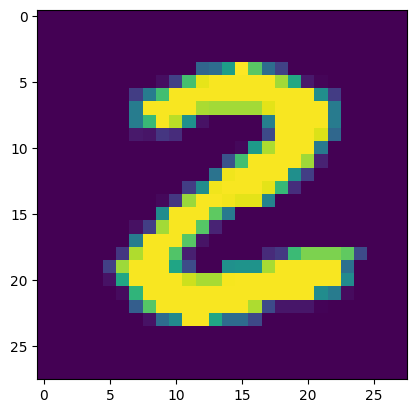

2


In [8]:
#displaying the image
plt.imshow(X_train[25])
plt.show()
#print corresponding label
print(Y_train[25])

In [9]:
#image label
print(Y_train.shape)
print(Y_test.shape)

(60000,)
(10000,)


In [10]:
#unique values in y train
print(np.unique(Y_train))

print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [11]:
#we can use these labels as such or we can also apple one hot encoding
#one hot encoding --if label is 0 in that case first value will be 1 and all other will be zero


In [12]:
#all the images have dimension in this dataset
#if not we have to resize to a common dimension




In [13]:
#scaling the values all the values are in the range of 0-250
#normalization
X_train = X_train/255
X_test  = X_test/255

#each value will be divided by 255


In [14]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building Neural Network

In [15]:
#here we are building basic NN

In [16]:
#setting up the layers of neural network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),  #feeding values to NN
    keras.layers.Dense(50,activation='relu'),   #input layer
    keras.layers.Dense(50,activation='relu'),   #hidden layer
    keras.layers.Dense(10,activation='sigmoid') #output_layer(10-classs in labels)

])




/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# loss=sparse_categorical_crossentrophy--when we have simple label encoding values



Training neural network

In [18]:
model.fit(X_train, Y_train, epochs=10 )  #trainingdata images-x_train

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8546 - loss: 0.5122
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9552 - loss: 0.1498
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9679 - loss: 0.1069
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9753 - loss: 0.0820
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9800 - loss: 0.0665
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9835 - loss: 0.0549
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9854 - loss: 0.0462
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9879 - loss: 0.0386
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9889 - loss: 0.0354
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9903 - loss: 0.0304


In [19]:
#accuracy for traring data is 99.06%
#accuracy for test data:

#model evaluation
loss,accuracy = model.evaluate(X_test,Y_test)  # y_test true label
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9667 - loss: 0.1238
0.968999981880188


In [20]:
#test data accuracy=96.35%

In [21]:
print(X_test.shape)

(10000, 28, 28)


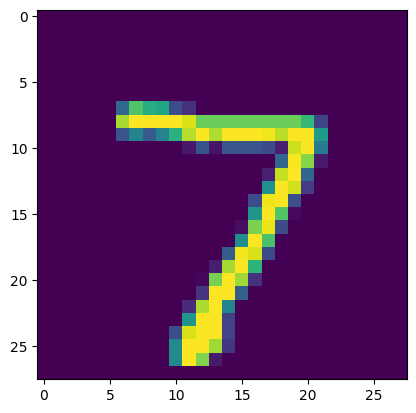

In [22]:
#first data point in X_test
plt.imshow(X_test[0])
plt.show()

In [23]:
print(Y_test[0])

7


In [24]:
Y_pred = model.predict(X_test)
print(Y_pred.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
(10000, 10)


In [25]:
print(Y_pred[0]) #prediction made by the model for this image

[4.63447592e-04 4.44008783e-03 8.89895391e-03 9.72976804e-01
 2.79374990e-09 4.20372486e-02 1.00101996e-10 9.99983311e-01
 1.26250200e-02 6.33278847e-01]


In [26]:
#probabity of each value

In [28]:
#converting prediction probablity to class label

label_for_First_image = np.argmax(Y_pred[0])  #index of maximum number in the array

7


In [29]:
#converting predicition probablity to class label for all test data points
#y_pred->probablity values
Y_pred_label =[ np.argmax(i) for i in Y_pred]
print(Y_pred_label)

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 2, 9, 9, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 9, 0, 3, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 6, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 9, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 6, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 6, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 9, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 8, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 8, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

In [30]:
print(Y_pred)

[[4.6344759e-04 4.4400878e-03 8.8989539e-03 ... 9.9998331e-01
  1.2625020e-02 6.3327885e-01]
 [3.6082763e-04 9.9948317e-01 1.0000000e+00 ... 1.7543337e-06
  4.5171324e-03 1.3172712e-15]
 [1.4028911e-04 9.9573153e-01 2.5581246e-02 ... 5.1971078e-01
  6.9450890e-03 1.1725026e-05]
 ...
 [8.0844689e-12 2.5984084e-05 1.0153890e-04 ... 5.1346719e-02
  8.5463951e-04 1.4101688e-03]
 [2.7246540e-04 2.8490056e-06 2.0134819e-05 ... 7.4312241e-09
  9.9807328e-01 2.6364789e-08]
 [4.2315400e-01 1.4263927e-07 5.5887863e-06 ... 8.5466203e-09
  1.6704324e-03 1.2870795e-03]]


In [31]:
#4.6344759e-04 4.4400878e-03 8.8989539e-03 ... 9.9998331e-01
#1.2625020e-02 6.3327885e-01 ->recognised as 7
#y_test is true labels and Y_pred label is predicted by NN

Confusion matrix

In [33]:
conf_mat = confusion_matrix(Y_test,Y_pred_label)
print(conf_mat)

tf.Tensor(
[[ 968    0    0    2    2    2    3    1    1    1]
 [   1 1122    1    1    1    1    4    2    2    0]
 [  11    0  981   15    6    2    1    9    6    1]
 [   0    0    2  996    0    1    0    5    3    3]
 [   0    0    1    0  967    0    5    3    0    6]
 [   5    0    0   17    1  857    5    2    4    1]
 [   4    1    1    0    9    3  940    0    0    0]
 [   2    1    7    6    2    1    0  997    1   11]
 [   4    2    3   25    6   14    6    3  908    3]
 [   1    2    0    7   29    9    0    7    2  952]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'Predicted label')

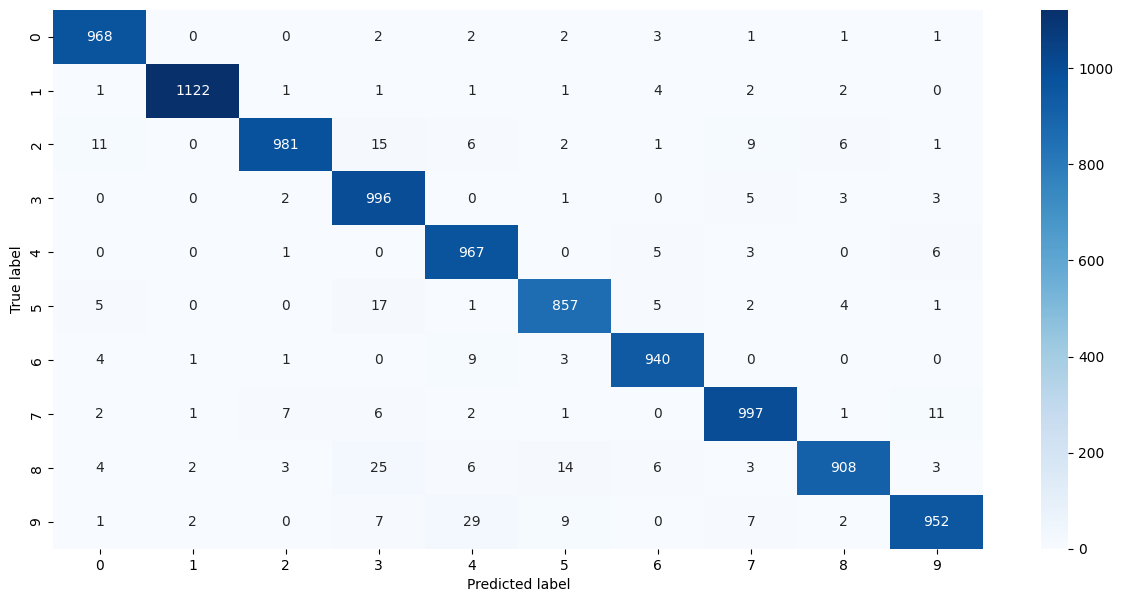

In [34]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [35]:
#all the values in blue represent the predicted label
# 968 images of zero are correctly predicted as 0
#true label is 0 but predicted as 1
#there are 3 images and all the 3 images is predicted as 6
#25 images of 8 is predicted as 3

In [36]:
#build predictive system

input_image_path ='/content/download.jpg'
input_image = cv2.imread(input_image_path)



In [37]:
#check type of input_image
type(input_image)

numpy.ndarray

In [38]:
print(input_image)

[[[247 247 247]
  [247 247 247]
  [247 247 247]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[ 85  85  85]
  [ 85  85  85]
  [ 85  85  85]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[  1   1   1]
  [  1   1   1]
  [  1   1   1]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]


In [39]:
input_image.shape

(188, 197, 3)

In [40]:
#3 means coloured image(RBG image)
#convert the image to grayscale image
gray_scale =cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)
print(gray_scale)

[[247 247 247 ... 255 255 255]
 [ 85  85  85 ... 255 255 255]
 [  1   1   1 ... 255 255 255]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]]


In [41]:
gray_scale.shape

(188, 197)

In [43]:
#resize image(convert to 28*28)
#resize image(convert to 28*28)
input_image_resize = cv2.resize(gray_scale, (28, 28))

In [44]:
input_image_resize.shape

(28, 28)

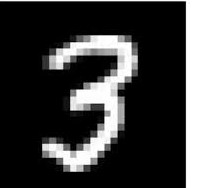

In [46]:
cv2_imshow(input_image)

In [47]:
#grading so that or values will be between 0 and 1
input_image_resize=(input_image_resize/255)

In [49]:
input_reshaped = np.reshape(input_image_resize,[1,28,28])


In [50]:
type(input_reshaped)

numpy.ndarray

In [51]:
input_prediction = model.predict(input_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[1.0714678e-17 2.6610718e-04 9.9999946e-01 1.0000000e+00 8.8843608e-21
  9.7562200e-01 2.1110290e-18 9.1785634e-01 1.8791061e-04 3.7368763e-20]]


In [52]:
input_print_label = np.argmax(input_prediction)
print(input_print_label)
#1.0000000e is the max value

3


#predictive System


path of the image to be imported/content/download.jpg


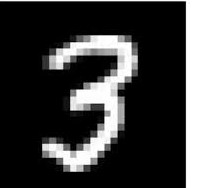

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The handwritten Digit is: 3


In [53]:
input_image_path =input('path of the image to be imported')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)
gray_scale =cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(gray_scale, (28, 28))

input_image_resize=(input_image_resize/255)

input_reshaped = np.reshape(input_image_resize,[1,28,28])

input_prediction = model.predict(input_reshaped)

input_print_label = np.argmax(input_prediction)
print('The handwritten Digit is:',input_print_label)
